# Heart Disease Prediction
## Notebook 4: Dimensionality Reduction

This notebook applies two dimensionality reduction techniques to the dataset.
Principal Component Analysis (PCA) is applied as an unsupervised technique to
identify directions of maximum variance. Linear Discriminant Analysis (LDA) is
applied as a supervised technique to find the direction that maximises class
separation between disease and no disease patients.

Both techniques are evaluated by training a Logistic Regression model on the
reduced feature space and comparing performance against full-feature models.

In [1]:
import os
import gc
import ctypes
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, roc_auc_score, accuracy_score

In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "splits")
RESULTS_DIR = os.path.join("..", "data", "processed", "results")
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

In [3]:
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_tree.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_tree.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Principal Component Analysis (PCA)

In [5]:
pca = PCA(n_components=None)
pca.fit(X_train_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.2049699  0.12356798 0.09973001 0.08128061 0.0759466  0.07140426
 0.06428377 0.05887692 0.05660697 0.05044176 0.04230827 0.03897483
 0.03160811]


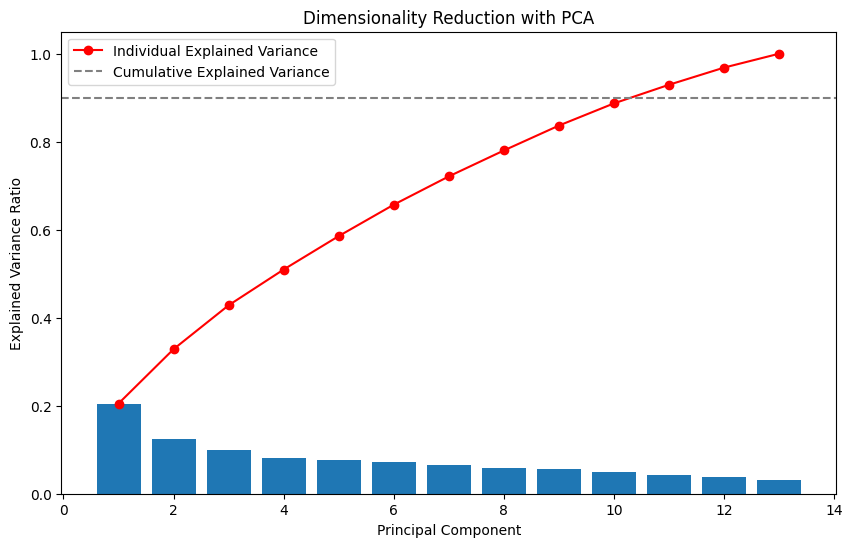

In [6]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, align='center')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='red')
plt.axhline(y=0.9, color='gray', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Dimensionality Reduction with PCA')
plt.legend(['Individual Explained Variance', 'Cumulative Explained Variance'])
plt.show()


In [7]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Reduced Shape: {X_train_pca.shape}")

Reduced Shape: (726, 10)


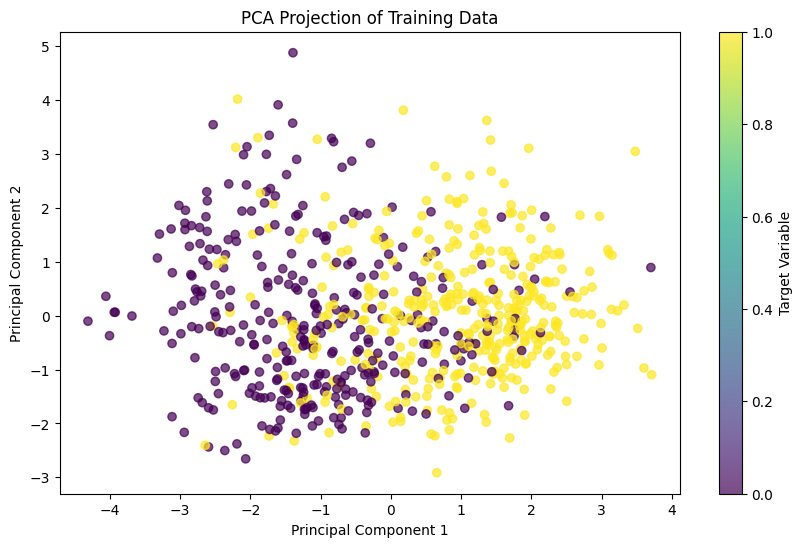

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train.values.squeeze(), cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Training Data')
plt.colorbar(label='Target Variable')
plt.show()

### Linear Discriminant Analysis (LDA)

Since PCA showed significant class overlap in 2D projection, we apply Linear Discriminant Analysis (LDA) - a supervised dimensionality reduction technique that explicitly maximises class separation rather than variance.

In [9]:
lda = LDA()
X_train_lda = lda.fit_transform(X_train_scaled, y_train.values.squeeze())
X_test_lda = lda.transform(X_test_scaled)

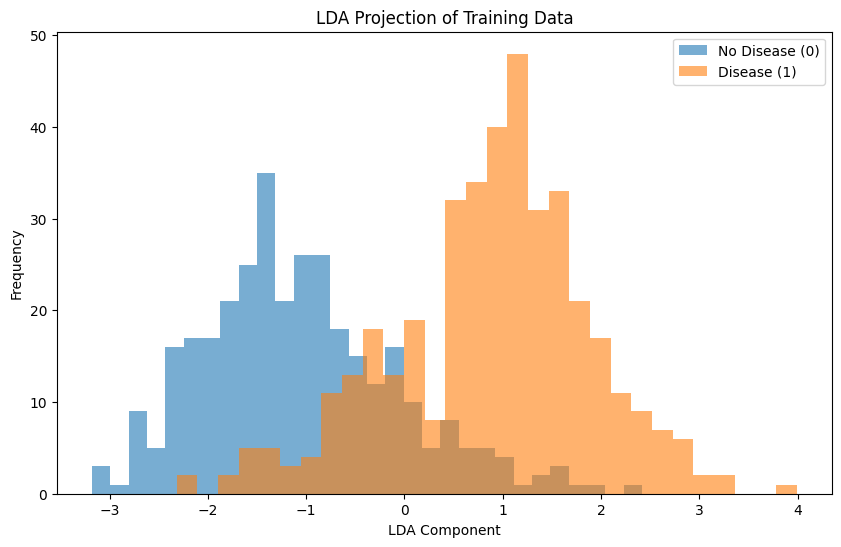

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(X_train_lda[y_train.values.squeeze() == 0], alpha=0.6, bins=30,label='No Disease (0)')
plt.hist(X_train_lda[y_train.values.squeeze() == 1], alpha=0.6, bins=30, label='Disease (1)')
plt.xlabel('LDA Component')
plt.ylabel('Frequency')
plt.title('LDA Projection of Training Data')
plt.legend()
plt.show()

LDA produces clear separation between classes along a single component, with No Disease patients clustering at negative values and Disease patients at positive values. The remaining overlap in the central region represents clinically ambiguous cases where features alone are insufficient for definitive classification. This contrasts sharply with PCA which showed near-complete class overlap, demonstrating that supervised dimensionality reduction is more informative than unsupervised for this classification task.

### Model Performance on Reduced Features

In [11]:
lr_pca = LogisticRegression()
lr_pca.fit(X_train_pca, y_train.values.squeeze())
y_pred_pca = lr_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)
roc_auc_pca = roc_auc_score(y_test.squeeze(), lr_pca.predict_proba(X_test_pca)[:, 1])
f2_score_pca = fbeta_score(y_test, y_pred_pca, beta=2)

print("PCA Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_pca))
print("PCA Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pca))
print("PCA Logistic Regression Accuracy:", accuracy_pca)
print("PCA Logistic Regression F2-Score:", f2_score_pca)
print("PCA Logistic Regression ROC AUC Score:", roc_auc_pca)

PCA Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        83
           1       0.81      0.84      0.83        99

    accuracy                           0.81       182
   macro avg       0.81      0.80      0.81       182
weighted avg       0.81      0.81      0.81       182

PCA Logistic Regression Confusion Matrix:
[[64 19]
 [16 83]]
PCA Logistic Regression Accuracy: 0.8076923076923077
PCA Logistic Regression F2-Score: 0.8333333333333334
PCA Logistic Regression ROC AUC Score: 0.8949738347328708


In [12]:
lr_lda = LogisticRegression()
lr_lda.fit(X_train_lda, y_train.values.squeeze())
y_pred_lda = lr_lda.predict(X_test_lda)

accuracy_lda = accuracy_score(y_test, y_pred_lda)
roc_auc_lda = roc_auc_score(y_test.squeeze(), lr_lda.predict_proba(X_test_lda)[:, 1])
f2_score_lda = fbeta_score(y_test, y_pred_lda, beta=2)

print("LDA Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lda))
print("LDA Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lda))
print("LDA Logistic Regression Accuracy:", accuracy_lda)
print("LDA Logistic Regression F2-Score:", f2_score_lda)
print("LDA Logistic Regression ROC AUC Score:", roc_auc_lda)

LDA Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80        83
           1       0.82      0.85      0.84        99

    accuracy                           0.82       182
   macro avg       0.82      0.82      0.82       182
weighted avg       0.82      0.82      0.82       182

LDA Logistic Regression Confusion Matrix:
[[65 18]
 [15 84]]
LDA Logistic Regression Accuracy: 0.8186813186813187
LDA Logistic Regression F2-Score: 0.8433734939759037
LDA Logistic Regression ROC AUC Score: 0.8983814044055008


In [13]:
results = {
    'lr_pca': {
        'accuracy': float(accuracy_pca),
        'roc_auc': float(roc_auc_pca),
        'f2_score': float(f2_score_pca)
    },
    'lr_lda': {
        'accuracy': float(accuracy_lda),
        'roc_auc': float(roc_auc_lda),
        'f2_score': float(f2_score_lda)
    }
}

with open(os.path.join(RESULTS_DIR, 'dr_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

In [14]:
# Clear all large variables explicitly
for var in ['X_train', 'X_test', 'y_train', 'y_test', 
            'base_rf', 'rf', 'best_rf',
            'base_xgb', 'xgb', 'best_xgb',
            'base_lr', 'lr', 'best_lr',
            'X_train_pca', 'X_test_pca',
            'X_train_lda', 'X_test_lda',
            'shap_values_rf', 'shap_values_xgb', 'shap_values_lr']:
    if var in dir():
        del var

gc.collect()

# Force release of memory back to OS (works on Windows)
if hasattr(ctypes, 'windll'):
    ctypes.windll.kernel32.SetProcessWorkingSetSize(-1, -1, -1)